In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from utils.data_utils import load_and_preprocess_data, vectorize_text

In [2]:
RANDOM_STATE = 42

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
DATA_PATH = '../../data/enron_spam_data.csv'

X, y, df = load_and_preprocess_data(
    filepath=DATA_PATH,
    text_columns=['Subject', 'Message'],
    target_column='Spam/Ham',
    combine_text=True,
    drop_na=True,
    positive_class='spam',  # spam = 1, ham = 0
    file_format='csv',
    verbose=True
)

Loading data from ../../data/enron_spam_data.csv...
Dataset shape: (33716, 5)

Column names: ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']

First few rows:
   Message ID                       Subject  \
0           0  christmas tree farm pictures   
1           1      vastar resources , inc .   
2           2  calpine daily gas nomination   
3           3                    re : issue   
4           4     meter 7268 nov allocation   

                                             Message Spam/Ham        Date  
0                                                NaN      ham  1999-12-10  
1  gary , production from the high island larger ...      ham  1999-12-13  
2             - calpine daily gas nomination 1 . doc      ham  1999-12-14  
3  fyi - see note below - already done .\nstella\...      ham  1999-12-14  
4  fyi .\n- - - - - - - - - - - - - - - - - - - -...      ham  1999-12-14  

Dropped 609 rows with NaN values
Shape after dropping NaN: (33107, 5)

Combined text columns:

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

In [5]:
X_train_vec, X_test_vec, vectorizer = vectorize_text(
    X_train, 
    X_test, 
    method='tfidf', 
    max_features=5000, 
    min_df=2,
    ngram_range=(1, 2), # unigrams & bigrams
    verbose=True
)

Vectorizing text using TFIDF...
Training set shape: (26485, 5000)
Test set shape: (6622, 5000)
Vocabulary size: 5000


In [6]:
X_train_np = X_train_vec.toarray().astype(np.float32)
X_test_np  = X_test_vec.toarray().astype(np.float32)

y_train_np = y_train.to_numpy().astype(np.float32).reshape(-1, 1)  # shape (N,1)
y_test_np  = y_test.to_numpy().astype(np.float32).reshape(-1, 1)

X_train_tensor = torch.from_numpy(X_train_np)
X_test_tensor  = torch.from_numpy(X_test_np)

y_train_tensor = torch.from_numpy(y_train_np)
y_test_tensor  = torch.from_numpy(y_test_np)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [7]:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout_p=0.3):
        super().__init__()
        self.neural_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 1)  # [batch, 1]
        )
    
    def forward(self, x):
        return self.neural_net(x)

input_dim = X_train_np.shape[1]
model = FeedForwardNet(input_dim=input_dim, hidden_dim=128, dropout_p=0.3).to(device)

In [8]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)  # shape [batch, 1]

        optimizer.zero_grad()
        logits = model(X_batch)       # shape [batch, 1]
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)


def eval_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)   # shape [batch, 1]
            loss = criterion(logits, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            all_logits.append(logits.cpu())
            all_labels.append(y_batch.cpu())

    all_logits = torch.cat(all_logits)   # shape [N,1]
    all_labels = torch.cat(all_labels)   # shape [N,1]

    return running_loss / len(loader.dataset), all_logits, all_labels

In [9]:
EPOCHS = 15

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, _, _ = eval_one_epoch(model, test_loader, criterion)
    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 01 | Train Loss: 0.1531 | Val Loss: 0.0456
Epoch 02 | Train Loss: 0.0298 | Val Loss: 0.0339
Epoch 03 | Train Loss: 0.0174 | Val Loss: 0.0310
Epoch 04 | Train Loss: 0.0112 | Val Loss: 0.0307
Epoch 05 | Train Loss: 0.0078 | Val Loss: 0.0312
Epoch 06 | Train Loss: 0.0054 | Val Loss: 0.0330
Epoch 07 | Train Loss: 0.0040 | Val Loss: 0.0344
Epoch 08 | Train Loss: 0.0030 | Val Loss: 0.0355
Epoch 09 | Train Loss: 0.0023 | Val Loss: 0.0372
Epoch 10 | Train Loss: 0.0019 | Val Loss: 0.0393
Epoch 11 | Train Loss: 0.0015 | Val Loss: 0.0419
Epoch 12 | Train Loss: 0.0013 | Val Loss: 0.0429
Epoch 13 | Train Loss: 0.0011 | Val Loss: 0.0461
Epoch 14 | Train Loss: 0.0010 | Val Loss: 0.0473
Epoch 15 | Train Loss: 0.0009 | Val Loss: 0.0491


Train Loss: 0.0007
Test Loss:  0.0491


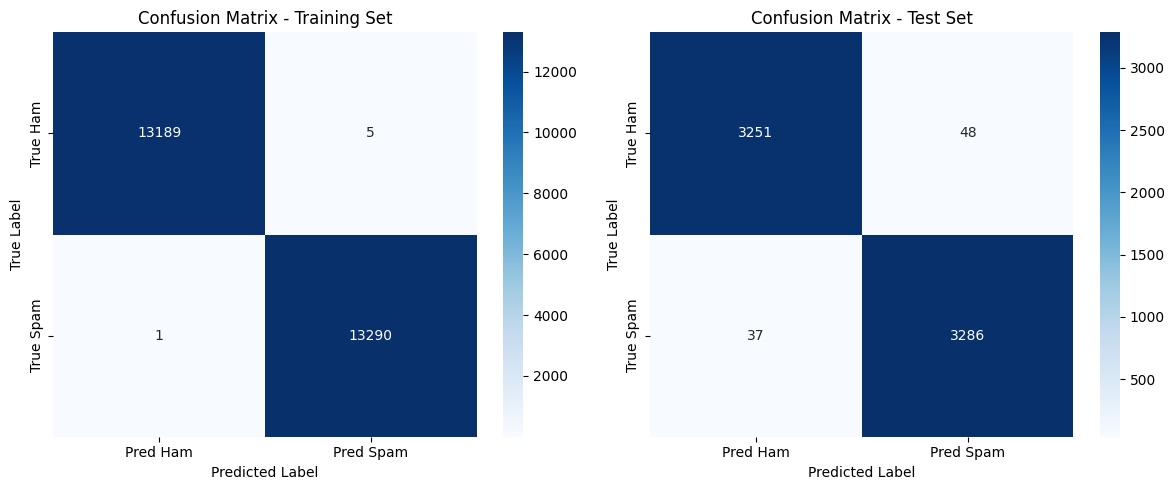

In [10]:
# 1. Evaluate on train and test
train_loss, train_logits, train_labels = eval_one_epoch(model, train_loader, criterion)
test_loss,  test_logits,  test_labels  = eval_one_epoch(model, test_loader,  criterion)

# 2. Convert logits -> probs -> preds (train)
train_probs = torch.sigmoid(train_logits).numpy()           # (N_train, 1)
train_preds = (train_probs >= 0.5).astype(int)              # (N_train, 1)
train_preds_flat  = train_preds.reshape(-1)
train_labels_flat = train_labels.numpy().reshape(-1).astype(int)

# 3. Convert logits -> probs -> preds (test)
test_probs = torch.sigmoid(test_logits).numpy()             # (N_test, 1)
test_preds = (test_probs >= 0.5).astype(int)                # (N_test, 1)
test_preds_flat  = test_preds.reshape(-1)
test_labels_flat = test_labels.numpy().reshape(-1).astype(int)

# 4. Confusion matrices
cm_train = confusion_matrix(train_labels_flat, train_preds_flat)
cm_test  = confusion_matrix(test_labels_flat,  test_preds_flat)

print(f"Train Loss: {train_loss:.4f}")
print(f"Test Loss:  {test_loss:.4f}")

# 5. Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_train, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred Ham', 'Pred Spam'],
    yticklabels=['True Ham', 'True Spam'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix - Training Set')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(
    cm_test, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Pred Ham', 'Pred Spam'],
    yticklabels=['True Ham', 'True Spam'],
    ax=axes[1]
)
axes[1].set_title('Confusion Matrix - Test Set')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [11]:
train_acc = accuracy_score(train_labels_flat, train_preds_flat)
test_acc = accuracy_score(test_labels_flat, test_preds_flat)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

Train Accuracy: 0.9998
Test  Accuracy: 0.9872


In [12]:
MODEL_PATH = "../../models/nn_model.pth"
torch.save(model.state_dict(), MODEL_PATH)

In [13]:
VECTORIZER_PATH = "../../models/nn_vectorizer.joblib"
joblib.dump(vectorizer, VECTORIZER_PATH)

print(f"Saved spam NN vectorizer to {VECTORIZER_PATH}")

Saved spam NN vectorizer to ../../models/nn_vectorizer.joblib
